# Лабораторна робота №3
## Візуалізація даних

### Обраний датасет
UCI Automobile Dataset

### Чому цей датасет підходить
- Multivariate
- Має categorical, integer, real атрибути
- Має пропущені значення

### План роботи
1. Завантаження датасету
2. Data Cleaning
3. Побудова 5–8 графіків
4. Висновки

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg",
    "highway-mpg", "price"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

df = pd.read_csv(url, header=None, names=columns, na_values="?")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [5]:
print("Shape:", df.shape)
df.info()

Shape: (205, 26)
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        2

In [6]:
df.isna().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [7]:
numeric_cols = [
    "normalized-losses", "bore", "stroke", "horsepower",
    "peak-rpm", "price"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = ["num-of-doors"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [8]:
df.describe(include="all")

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205.000000,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
unique,NaN,NaN,22,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,185,168,116,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.834146,120.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329366,3.256098,10.142537,104.165854,5126.097561,25.219512,30.751220,13150.307317
std,1.245307,31.805105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.270858,0.313634,3.972040,39.529733,477.035772,6.542142,6.886443,7879.121326
min,-2.000000,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,115.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000


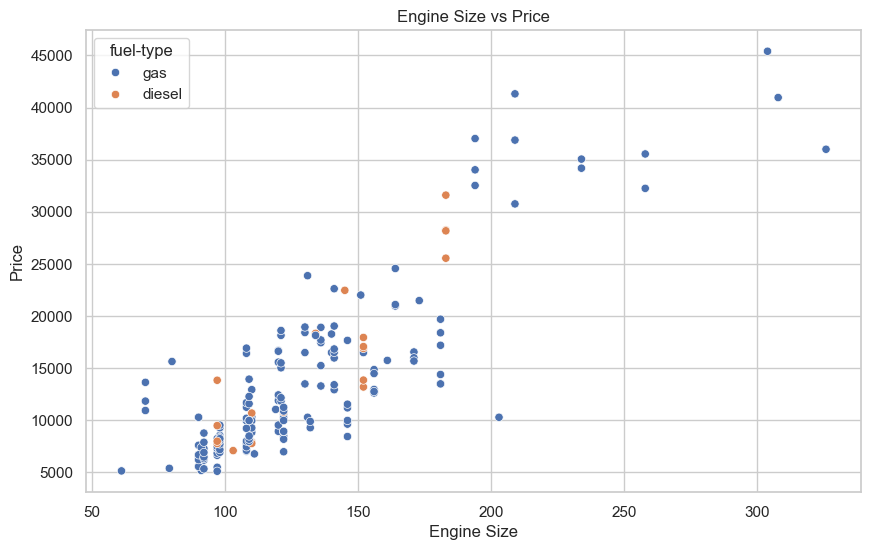

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="engine-size", y="price", hue="fuel-type")
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

**Висновок:** зі збільшенням об'єму двигуна ціна автомобіля зазвичай зростає.

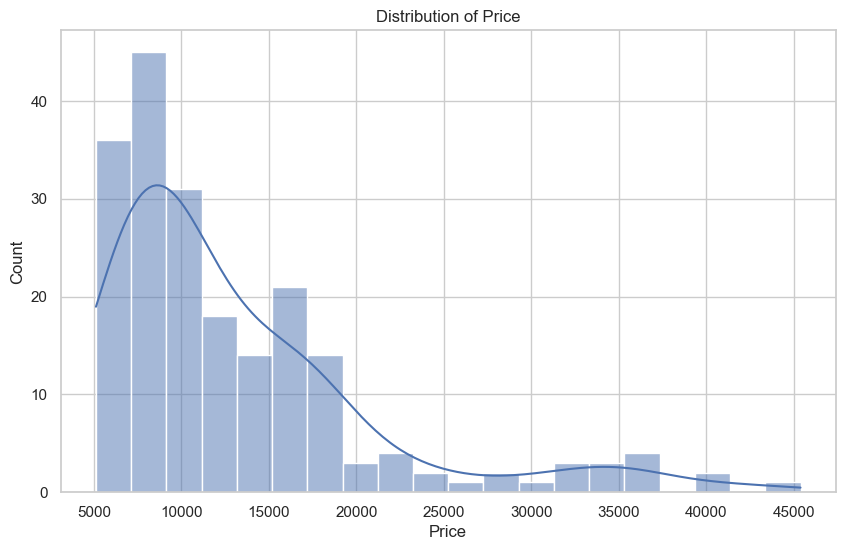

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df["price"], bins=20, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

**Висновок:** більшість автомобілів зосереджені в нижньому та середньому цінових діапазонах.

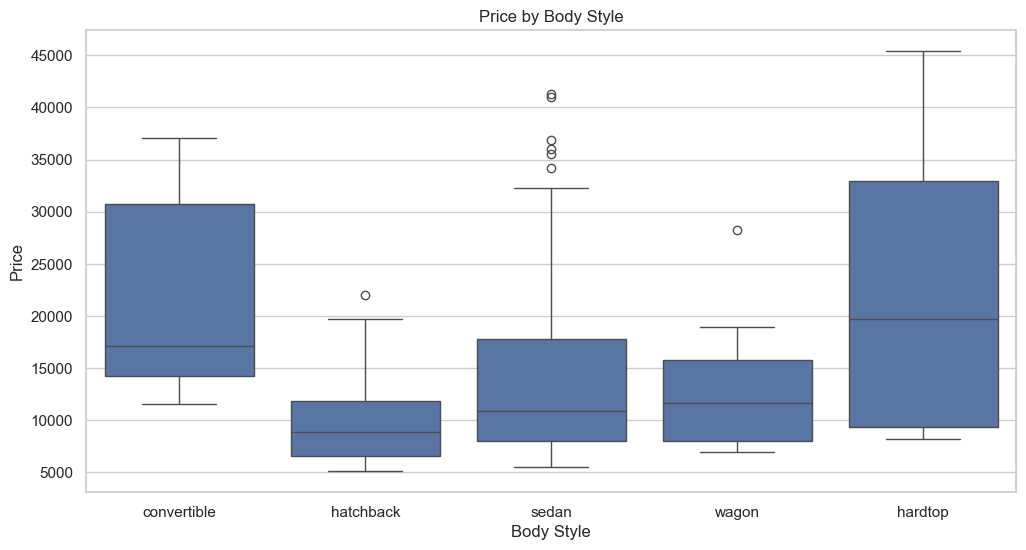

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="body-style", y="price")
plt.title("Price by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.show()

**Висновок:** різні типи кузова мають різний розподіл цін, є викиди.

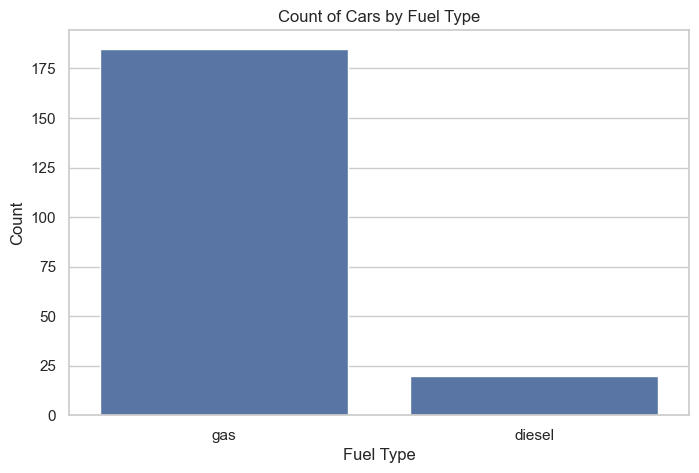

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="fuel-type")
plt.title("Count of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

**Висновок:** бензинових автомобілів у датасеті більше, ніж дизельних.

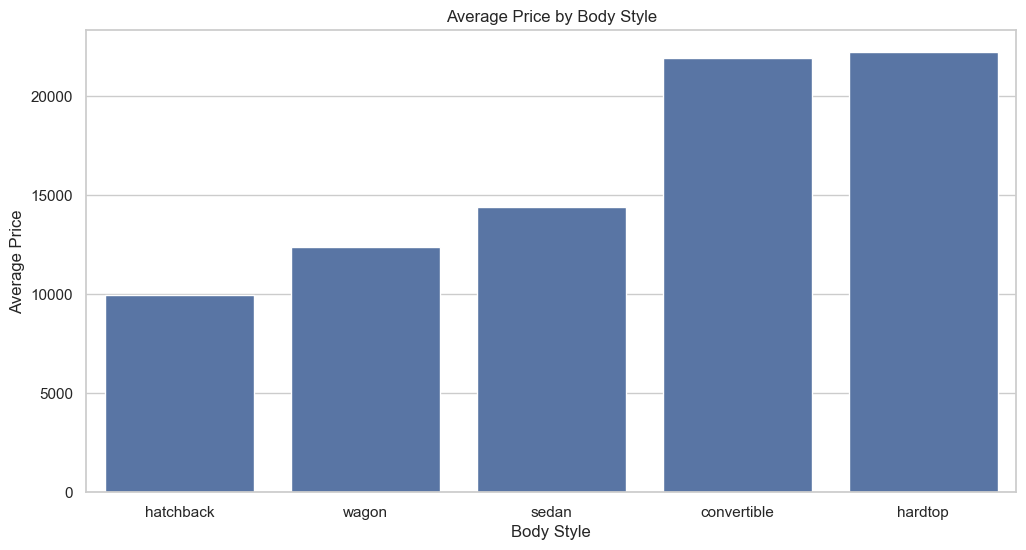

In [13]:
plt.figure(figsize=(12, 6))
avg_price_body = df.groupby("body-style")["price"].mean().sort_values()
sns.barplot(x=avg_price_body.index, y=avg_price_body.values)
plt.title("Average Price by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Average Price")
plt.show()

**Висновок:** середня ціна залежить від типу кузова.

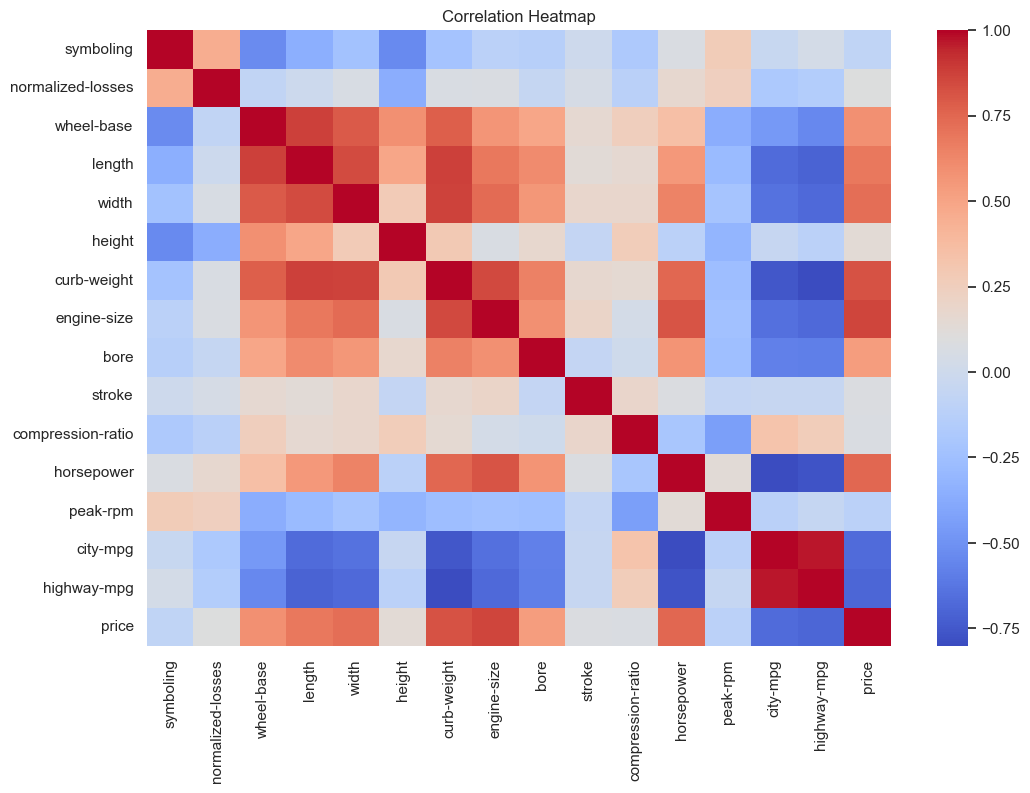

In [15]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

**Висновок:** ціна має помітний зв'язок з потужністю, розміром двигуна та масою автомобіля.

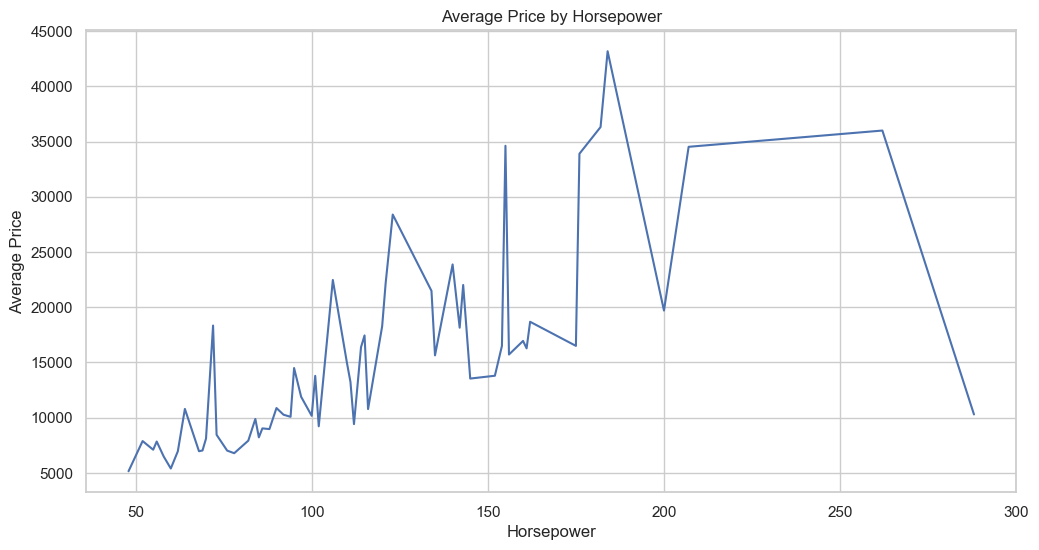

In [16]:
temp_df = df[["horsepower", "price"]].copy()
temp_df["horsepower"] = temp_df["horsepower"].astype(int)
temp_df = temp_df.sort_values("horsepower")

avg_price_hp = temp_df.groupby("horsepower", as_index=False)["price"].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_price_hp, x="horsepower", y="price")
plt.title("Average Price by Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Average Price")
plt.show()

**Висновок:** із ростом потужності двигуна середня ціна автомобіля загалом підвищується.

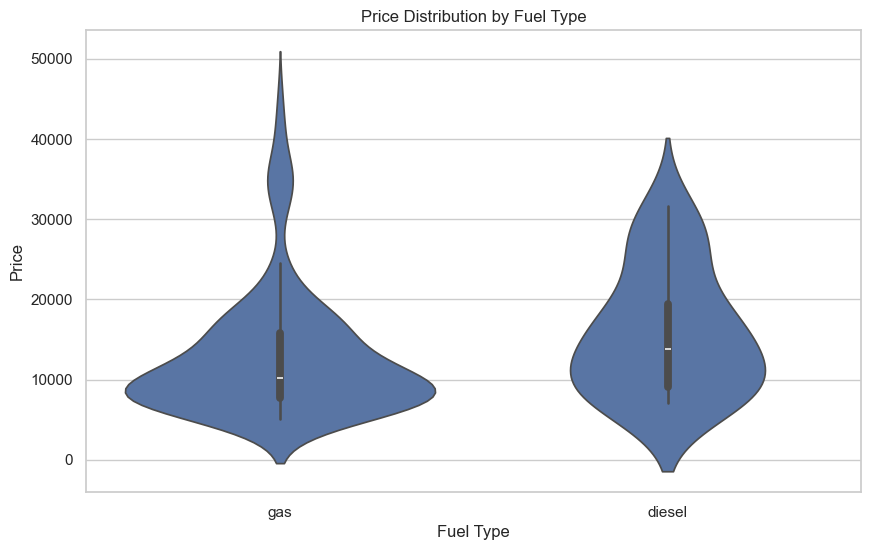

In [17]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="fuel-type", y="price")
plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()

**Висновок:** розподіл цін для різних типів пального відрізняється.

## Загальний висновок

У ході лабораторної роботи було:
- обрано датасет, що відповідає умовам завдання;
- виконано очищення даних;
- побудовано 8 графіків;
- проаналізовано залежності між числовими та категоріальними ознаками.

Найбільший вплив на ціну автомобіля мають характеристики двигуна, потужність та маса автомобіля.